# Setup inicial

In [7]:
# Importação das bibliotecas necessárias para a análise
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itables

# Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Iniciando o download do dataset do Kaggle")

# Download da versão mais recente do dataset
path = kagglehub.dataset_download("michaelhakim/walmart-sales-analysis")
print(f"Download concluído. Arquivos salvos em: {path}")

# Busca automática pelo arquivo CSV dentro da pasta baixada
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    # Pega o primeiro CSV encontrado (esperado ser a base do Walmart)
    file_path = os.path.join(path, csv_files[0])
    print(f"Carregando o arquivo: {csv_files[0]}\n")
    
    # Carregamento dos dados no DataFrame
    df = pd.read_csv(file_path)
    
    # Exibição das primeiras 5 linhas para validação
    itables.show(df.head())
    
    # Exibição de informações gerais da base (tipos de dados e nulos)
    print("\nInformações do Dataset:")
    itables.show(df.info())
else:
    print("Erro: Nenhum arquivo CSV foi encontrado na pasta especificada.")

Iniciando o download do dataset do Kaggle
Download concluído. Arquivos salvos em: C:\Users\mateu\.cache\kagglehub\datasets\michaelhakim\walmart-sales-analysis\versions\6
Carregando o arquivo: Walmart_sales_analysis.csv



Loading ITables v2.8.0 from the internet... (need help?)



Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store_Number  6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   object 
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6    CPI          6435 non-null   int64  
 7   Unemployment  6435 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 402.3+ KB


Loading ITables v2.8.0 from the internet... (need help?)


# Limpeza e Tratamento dos Dados

In [12]:
print("Iniciando limpeza e formatação dos dados...\n")

# 1. Remover espaços em branco dos nomes das colunas
df.columns = df.columns.str.strip()

# 2. Limpar a coluna Weekly_Sales
df['Weekly_Sales'] = df['Weekly_Sales'].astype(str).str.replace(r'[$,]', '', regex=True).astype(float)

# 3. Converter a coluna Date para o tipo datetime do Pandas (CORREÇÃO)
# Informamos explicitamente que o formato é Mês/Dia/Ano
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# 3.1 Converter temperatura de Fahrenheit para Celsius (CORREÇÃO)
df['Temperature'] = (df['Temperature'] - 32) * 5.0/9.0

# 4. Ordenar o DataFrame pela loja e data para facilitar a análise
df = df.sort_values(by=['Store_Number', 'Date']).reset_index(drop=True)

# Validação pós-limpeza
print("Tipos de dados corrigidos:")
display(df.dtypes)

print("\nResumo estatístico das vendas limpas:")
display(df['Weekly_Sales'].describe())

Iniciando limpeza e formatação dos dados...

Tipos de dados corrigidos:


Store_Number             int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                      int64
Unemployment           float64
dtype: object


Resumo estatístico das vendas limpas:


count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099860e+05
25%      5.533500e+05
50%      9.607460e+05
75%      1.420158e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

In [13]:
# Raio-X de negócio

# 1. Escopo de Tempo e Estrutura
print("1. PERÍODO E LOJAS:")
print(f"Data Inicial: {df['Date'].min().strftime('%d/%m/%Y')}")
print(f"Data Final: {df['Date'].max().strftime('%d/%m/%Y')}")
print(f"Total de Lojas Únicas: {df['Store_Number'].nunique()} lojas")
print(f"Total de Registros (Semanas): {len(df)} linhas\n")

# 2. Verificando se todas as lojas têm a mesma quantidade de dados (Linhas por Loja)
linhas_por_loja = df['Store_Number'].value_counts()
print("2. QUANTIDADE DE DADOS POR LOJA:")
print(f"As lojas têm entre {linhas_por_loja.min()} e {linhas_por_loja.max()} semanas de dados registradas.\n")

# 3. O peso dos Feriados (Holiday_Flag: 0 = Normal, 1 = Feriado)
print("3. IMPACTO DOS FERIADOS NAS VENDAS MÉDIAS:")
vendas_feriado = df.groupby('Holiday_Flag')['Weekly_Sales'].mean().reset_index()
vendas_feriado['Holiday_Flag'] = vendas_feriado['Holiday_Flag'].map({0: 'Semana Normal', 1: 'Semana com Feriado'})
# Formatando para Moeda (Dólar) para facilitar a leitura
vendas_feriado['Weekly_Sales'] = vendas_feriado['Weekly_Sales'].apply(lambda x: f"${x:,.2f}")
itables.show(vendas_feriado)

# 4. Visão Geral do Cenário Econômico Médio (As outras variáveis)
print("\n4. MÉDIAS DO CENÁRIO ECONÔMICO GERAL:")
cenario_medio = pd.DataFrame({
    'Métrica': ['Desemprego Médio', 'Inflação (CPI) Média', 'Preço Médio Combustível', 'Temperatura Média (F)'],
    'Valor': [
        f"{df['Unemployment'].mean():.2f}%",
        f"{df['CPI'].mean():.2f}",
        f"${df['Fuel_Price'].mean():.2f}",
        f"{df['Temperature'].mean():.2f}°C"
    ]
})
itables.show(cenario_medio)

1. PERÍODO E LOJAS:
Data Inicial: 05/02/2010
Data Final: 26/10/2012
Total de Lojas Únicas: 45 lojas
Total de Registros (Semanas): 6435 linhas

2. QUANTIDADE DE DADOS POR LOJA:
As lojas têm entre 143 e 143 semanas de dados registradas.

3. IMPACTO DOS FERIADOS NAS VENDAS MÉDIAS:


Loading ITables v2.8.0 from the internet... (need help?)



4. MÉDIAS DO CENÁRIO ECONÔMICO GERAL:


Loading ITables v2.8.0 from the internet... (need help?)


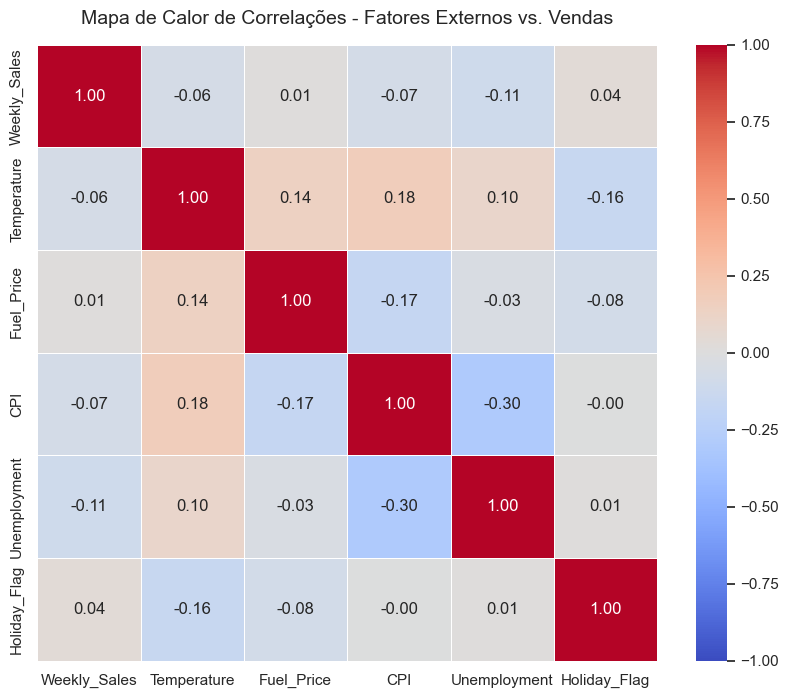

In [16]:
#Heatmap

# Selecionar apenas as colunas numéricas para a correlação
colunas_analise = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']

# Calcular a matriz de correlação de Pearson
matriz_corr = df[colunas_analise].corr()

# Plotar o Heatmap (Mapa de Calor)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Calor de Correlações - Fatores Externos vs. Vendas', fontsize=14, pad=15)
plt.show()

##### Modelo de correlação provou matematicamente a tese do Varejo Anticíclico. O Walmart vende itens de necessidade básica e opera no modelo de descontos. Como a correlação com a Inflação (-0.07) e o Desemprego (-0.11) é baixíssima, isso prova que mesmo em cenários de crise econômica, o faturamento da empresa não despenca de forma linear. Pelo contrário: quando o custo de vida sobe, clientes de supermercados mais caros migram para o Walmart em busca de preços baixos, mantendo o faturamento estável